#  Credit Rating Prediction — Regression
### XGBoost vs LightGBM vs CatBoost

**Goal:** Predict the `Rating` value using all other features  
**Metric:** Mean Absolute Error (MAE) — lower is better


In [1]:
!pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
print('All libraries imported successfully ')

All libraries imported successfully 



## 2. Load the Dataset

In [3]:
df = pd.read_csv('Credit_Data 2.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (400, 12)


,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Info & Missing Values

In [4]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values per Column ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')
print(f'Missing in Age column: {df["Age"].isnull().sum()}')

print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Data Types ===
ID             int64
Income       float64
Limit          int64
Rating         int64
Cards          int64
Age            int64
Education      int64
Gender        object
Student       object
Married       object
Ethnicity     object
Balance        int64
dtype: object

=== Missing Values per Column ===
ID           0
Income       0
Limit        0
Rating       0
Cards        0
Age          0
Education    0
Gender       0
Student      0
Married      0
Ethnicity    0
Balance      0
dtype: int64

Total missing values: 0
Missing in Age column: 0

=== Descriptive Statistics ===


,ID,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,200.50,45.22,4735.60,354.94,2.96,55.67,13.45,520.02
std,115.61,35.24,2308.20,154.72,1.37,17.25,3.13,459.76
min,1.00,10.35,855.00,93.00,1.00,23.00,5.00,0.00
25%,100.75,21.01,3088.00,247.25,2.00,41.75,11.00,68.75
50%,200.50,33.12,4622.50,344.00,3.00,56.00,14.00,459.50
75%,300.25,57.47,5872.75,437.25,4.00,70.00,16.00,863.00
max,400.00,186.63,13913.00,982.00,9.00,98.00,20.00,1999.00


### 3.2 Target Variable Distribution (Rating)

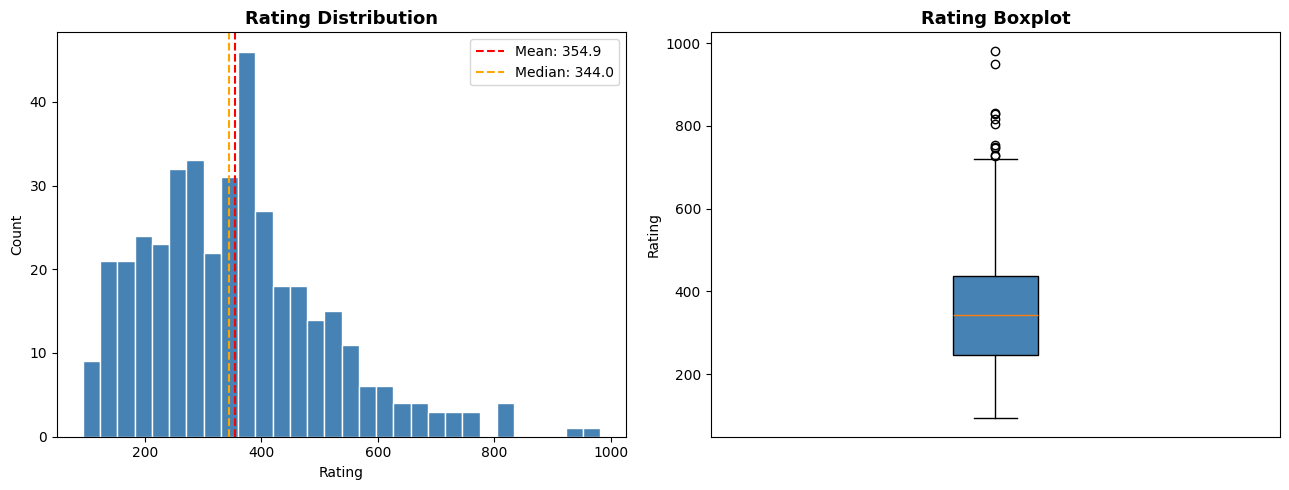

Min: 93 | Max: 982 | Mean: 354.9 | Std: 154.7


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['Rating'].mean(),   color='red',    linestyle='--', label=f"Mean: {df['Rating'].mean():.1f}")
axes[0].axvline(df['Rating'].median(), color='orange', linestyle='--', label=f"Median: {df['Rating'].median():.1f}")
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['Rating'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'))
axes[1].set_title('Rating Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rating')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"Min: {df['Rating'].min()} | Max: {df['Rating'].max()} | Mean: {df['Rating'].mean():.1f} | Std: {df['Rating'].std():.1f}")

### 3.3 Numeric Feature Distributions

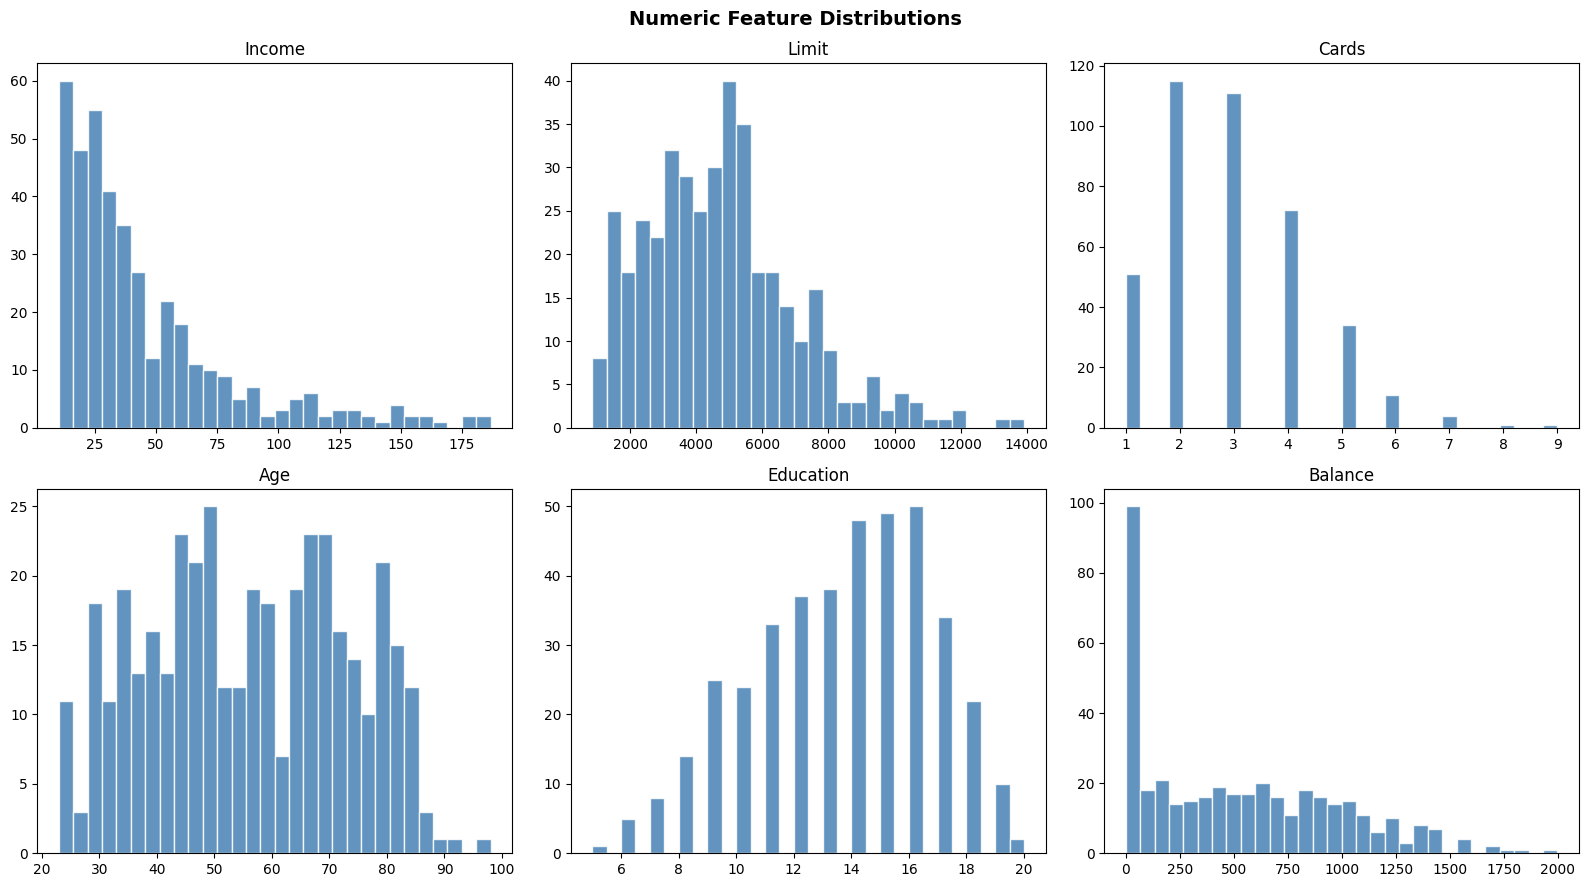

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.drop(['ID', 'Rating']).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Categorical Feature Distributions

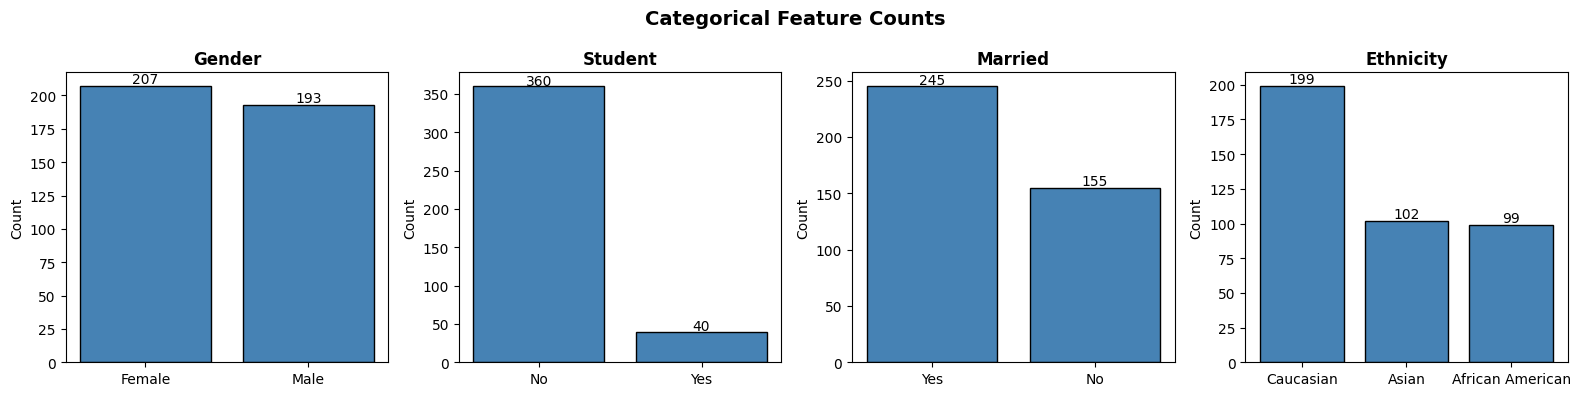

In [7]:
cat_cols_viz = ['Gender', 'Student', 'Married', 'Ethnicity']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, cat_cols_viz):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha='center', fontsize=10)

plt.suptitle('Categorical Feature Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

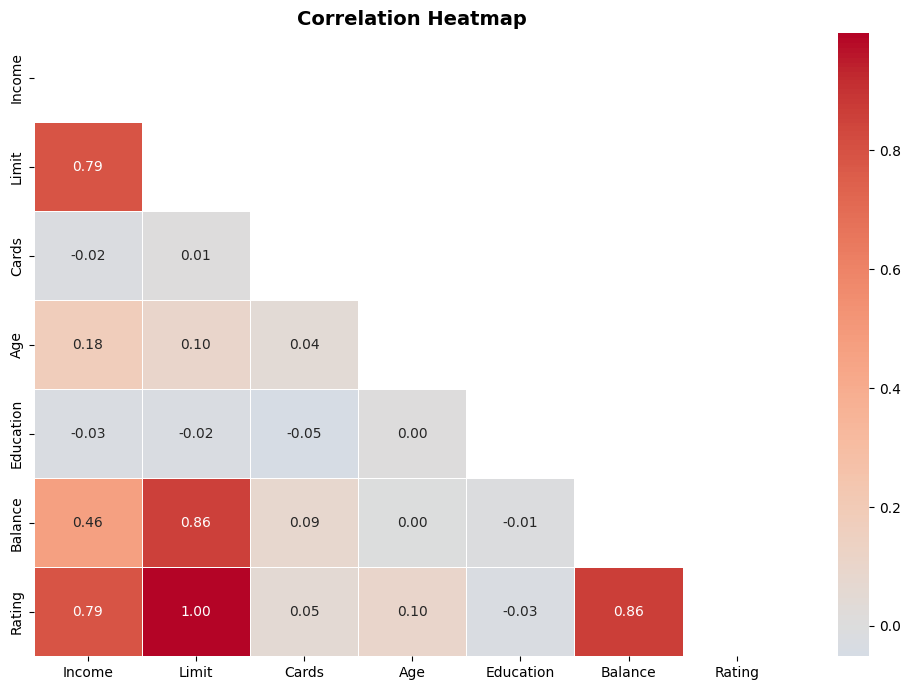

Top features correlated with Rating:
Limit        0.997
Balance      0.864
Income       0.791
Age          0.103
Cards        0.053
Education    0.030
Name: Rating, dtype: float64


In [8]:
corr_cols = numeric_cols + ['Rating']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features correlated with Rating:')
print(corr['Rating'].drop('Rating').abs().sort_values(ascending=False).round(3))

### 3.6 Scatter Plots: Top Features vs Rating

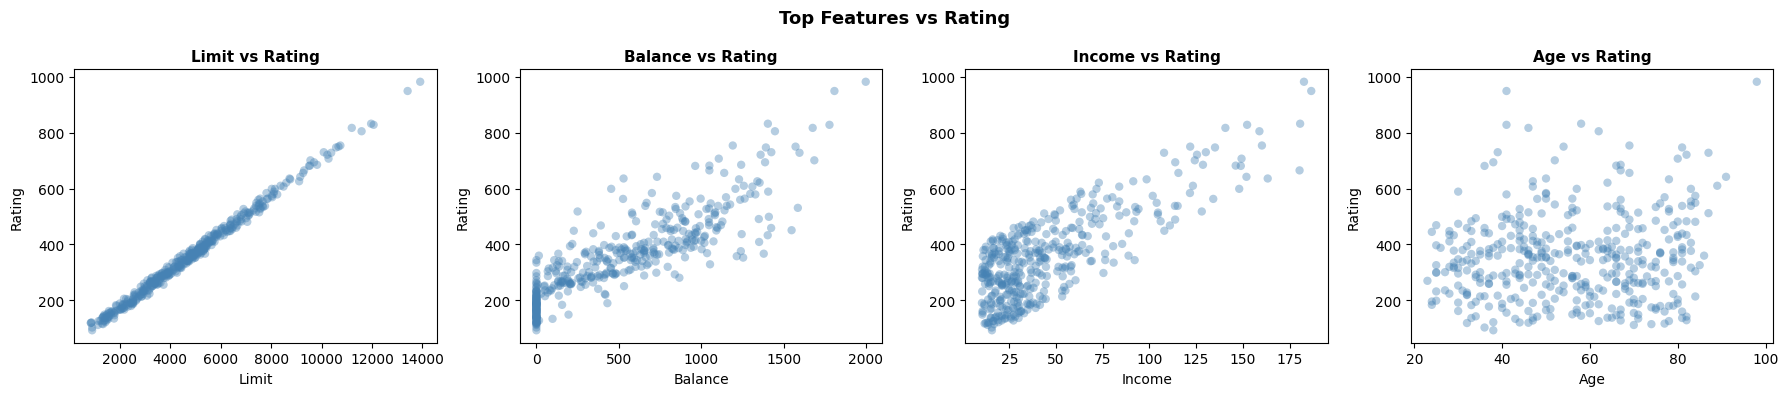

In [9]:
top_features = corr['Rating'].drop('Rating').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['Rating'], alpha=0.4, color='steelblue', edgecolors='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('Rating')
    ax.set_title(f'{feat} vs Rating', fontsize=11, fontweight='bold')

plt.suptitle('Top Features vs Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing
### 4.1 Drop ID Column

In [10]:
df = df.drop(columns=['ID'])
print('ID column dropped ')
print(f'Remaining columns: {df.columns.tolist()}')

ID column dropped 
Remaining columns: ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender', 'Student', 'Married', 'Ethnicity', 'Balance']


### 4.2 Encode Categorical Columns

In [11]:
cat_cols = ['Gender', 'Student', 'Married', 'Ethnicity']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'{col}: encoded ')

print('\nSample after encoding:')
df.head(3)

Gender: encoded 
Student: encoded 
Married: encoded 
Ethnicity: encoded 

Sample after encoding:


,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,1,0,1,2,333
1,106.025,6645,483,3,82,15,0,1,1,1,903
2,104.593,7075,514,4,71,11,1,0,0,1,580


### 4.3 Define Features & Target

In [12]:
X = df.drop(columns=['Rating'])
y = df['Rating']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Feature columns: {X.columns.tolist()}')

Features shape: (400, 10)
Target shape:   (400,)
Feature columns: ['Income', 'Limit', 'Cards', 'Age', 'Education', 'Gender', 'Student', 'Married', 'Ethnicity', 'Balance']


### 4.4 Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train samples: {X_train.shape[0]}')
print(f'Test samples:  {X_test.shape[0]}')

Train samples: 320
Test samples:  80


---
## 5. Model Training (Default Settings)

In [14]:
models_default = {
    'XGBoost':  XGBRegressor(random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(random_seed=SEED, verbose=0)
}

default_results = {}

print('Training all models with default settings...\n')
print(f'{"Model":<12} | {"MAE":>8} | {"RMSE":>8} | {"R2":>6} | Train Time')
print('-' * 58)

for name, model in models_default.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    default_results[name] = {
        'MAE':            round(mae,  4),
        'RMSE':           round(rmse, 4),
        'R2':             round(r2,   4),
        'Train Time (s)': round(train_time, 4),
        'model':          model,
        'y_pred':         y_pred
    }

    print(f'{name:<12} | {mae:>8.4f} | {rmse:>8.4f} | {r2:>6.4f} | {train_time:.4f}s')

Training all models with default settings...

Model        |      MAE |     RMSE |     R2 | Train Time
----------------------------------------------------------
XGBoost      |  11.3831 |  14.6919 | 0.9868 | 0.1455s
LightGBM     |  15.3062 |  21.0632 | 0.9729 | 0.0678s
CatBoost     |  11.2742 |  14.6584 | 0.9869 | 1.5384s



## 6. Model Evaluation
### 6.1 Actual vs Predicted Plots

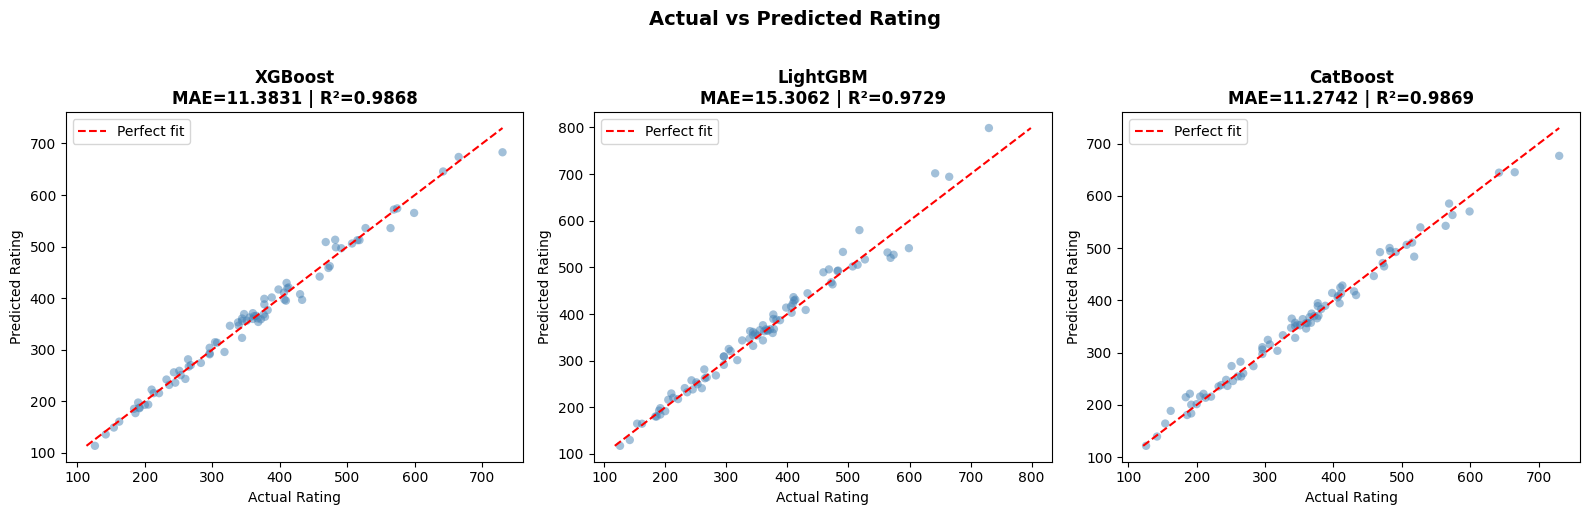

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, default_results.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.5, color='steelblue', edgecolors='none')
    min_val = min(y_test.min(), res['y_pred'].min())
    max_val = max(y_test.max(), res['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Rating')
    ax.set_ylabel('Predicted Rating')
    ax.set_title(f'{name}\nMAE={res["MAE"]} | R²={res["R2"]}', fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Residual Plots

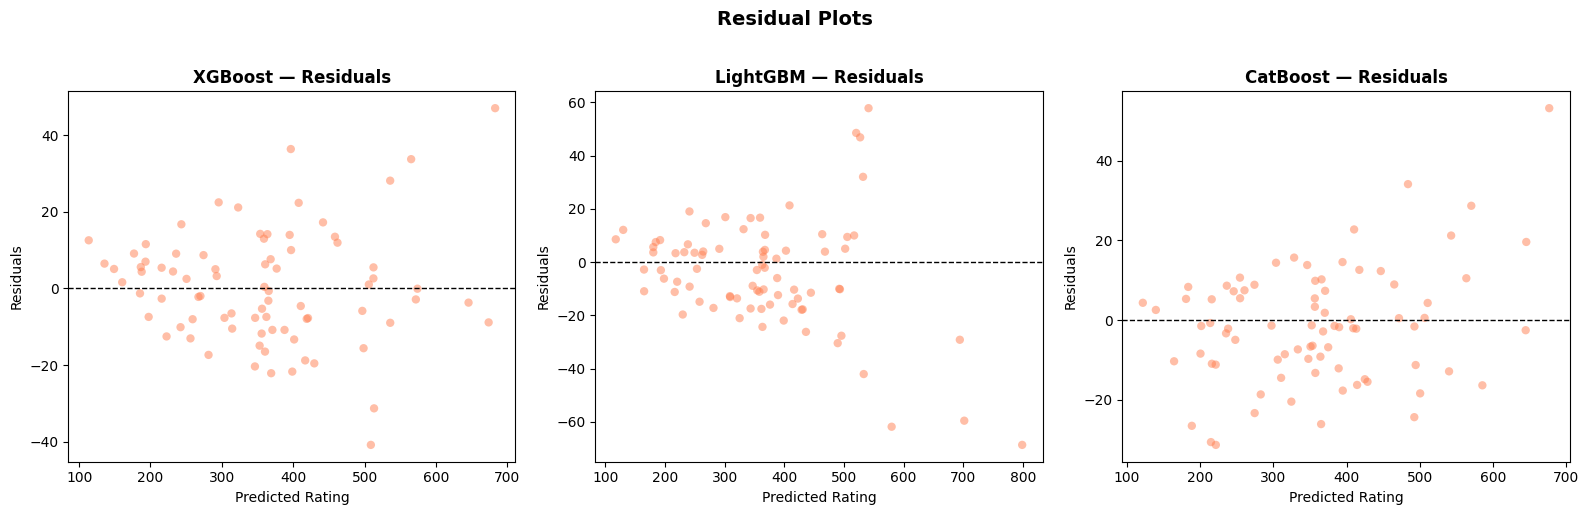

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, default_results.items()):
    residuals = y_test.values - res['y_pred']
    ax.scatter(res['y_pred'], residuals, alpha=0.5, color='coral', edgecolors='none')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Rating')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} — Residuals', fontsize=12, fontweight='bold')

plt.suptitle('Residual Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 MAE, R², and Train Time Comparison

=== Default Settings — Full Comparison ===
   Model     MAE    RMSE     R2  Train Time (s)
CatBoost 11.2742 14.6584 0.9869          1.5384
 XGBoost 11.3831 14.6919 0.9868          0.1455
LightGBM 15.3062 21.0632 0.9729          0.0678


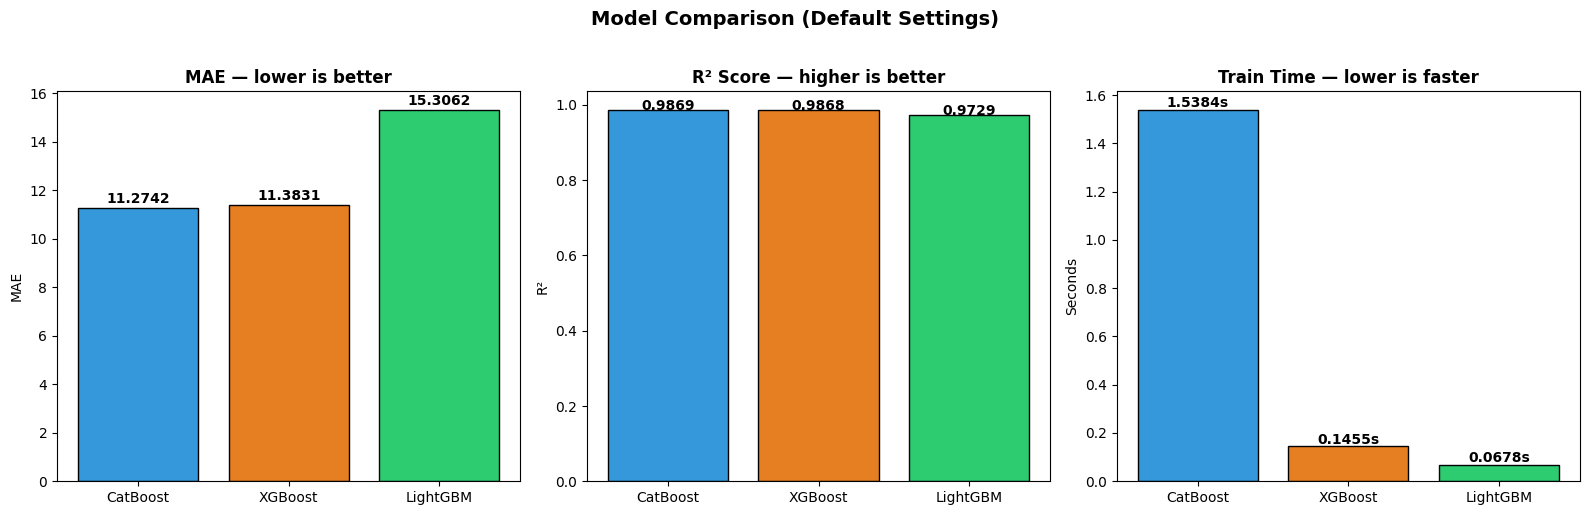

In [17]:
summary_df = pd.DataFrame([
    {
        'Model':          name,
        'MAE':            res['MAE'],
        'RMSE':           res['RMSE'],
        'R2':             res['R2'],
        'Train Time (s)': res['Train Time (s)']
    }
    for name, res in default_results.items()
]).sort_values('MAE').reset_index(drop=True)

print('=== Default Settings — Full Comparison ===')
print(summary_df.to_string(index=False))

colors = ['#3498db', '#e67e22', '#2ecc71']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE
axes[0].bar(summary_df['Model'], summary_df['MAE'], color=colors, edgecolor='black')
axes[0].set_title('MAE — lower is better', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE')
for i, v in enumerate(summary_df['MAE']):
    axes[0].text(i, v + 0.2, f'{v:.4f}', ha='center', fontweight='bold')

# R2
axes[1].bar(summary_df['Model'], summary_df['R2'], color=colors, edgecolor='black')
axes[1].set_title('R² Score — higher is better', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
for i, v in enumerate(summary_df['R2']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Train Time
axes[2].bar(summary_df['Model'], summary_df['Train Time (s)'], color=colors, edgecolor='black')
axes[2].set_title('Train Time — lower is faster', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seconds')
for i, v in enumerate(summary_df['Train Time (s)']):
    axes[2].text(i, v + 0.01, f'{v:.4f}s', ha='center', fontweight='bold')

plt.suptitle('Model Comparison (Default Settings)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Feature Importance

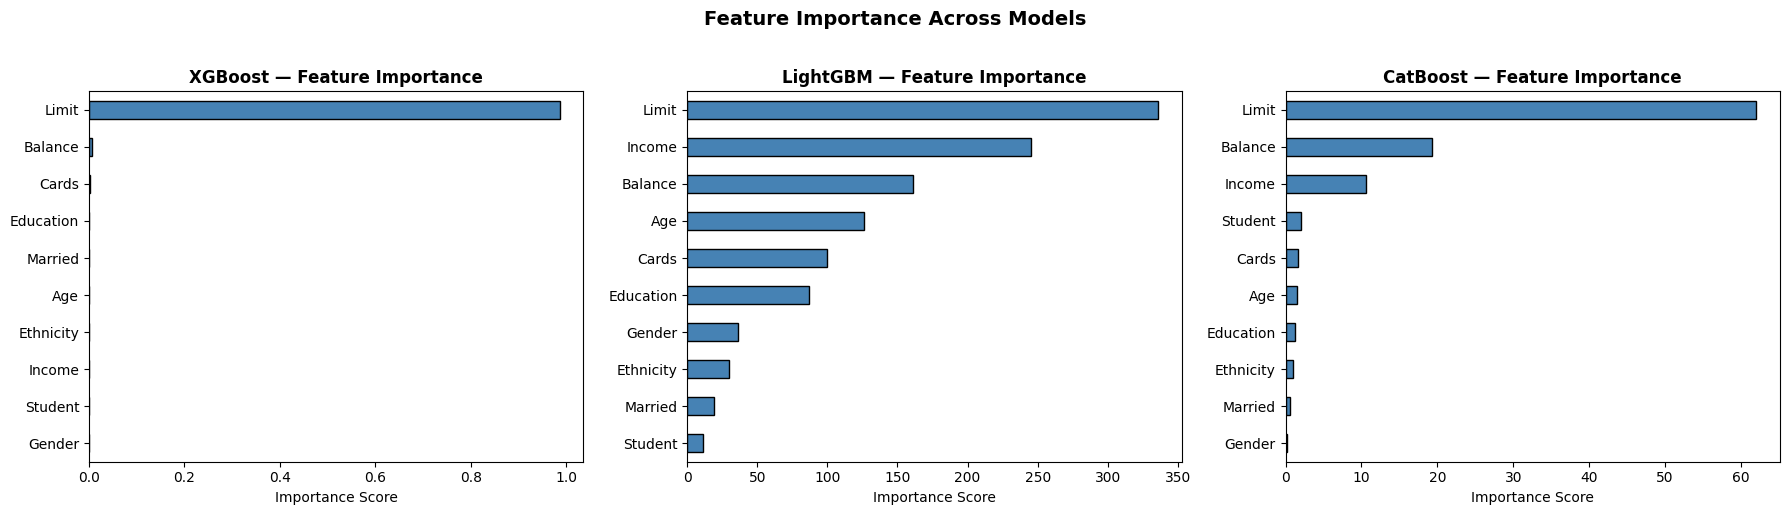

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, default_results.items()):
    model = res['model']
    importances = (
        model.get_feature_importance()
        if name == 'CatBoost'
        else model.feature_importances_
    )
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{name} — Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Across Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Final Summary

In [19]:
best_row    = summary_df.iloc[0]
fastest_row = summary_df.sort_values('Train Time (s)').iloc[0]
xgb_row     = summary_df[summary_df['Model'] == 'XGBoost'].iloc[0]

xgb_model   = default_results['XGBoost']['model']
xgb_imp     = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_feature = xgb_imp.idxmax()

print('=' * 58)
print('     CREDIT RATING REGRESSION — FINAL SUMMARY')
print('=' * 58)
print(f'  Dataset:             400 samples, 10 features')
print(f'  Target:              Rating (continuous numeric)')
print(f'  Missing in Age:      {df["Age"].isnull().sum()}')
print(f'  Metric:              Mean Absolute Error (MAE)')
print()
print(f'  {"Model":<12} | {"MAE":>8} | {"R2":>6} | {"Train Time"}')
print(f'  {"-"*52}')
for _, row in summary_df.iterrows():
    marker = '  ← BEST MAE' if row['Model'] == best_row['Model'] else ''
    print(f"  {row['Model']:<12} | {row['MAE']:>8.4f} | {row['R2']:>6.4f} | {row['Train Time (s)']:.4f}s{marker}")
print()
print(f"  🏆 Best MAE model:        {best_row['Model']} (MAE = {best_row['MAE']})")
print(f"  ⚡ Fastest training:      {fastest_row['Model']} ({fastest_row['Train Time (s)']:.4f}s)")
print(f"  XGBoost MAE:             {xgb_row['MAE']}")
print(f"  XGBoost top feature:     {top_feature}")
print()
print('  Key Observations:')
print('  • Limit dominates all other features in XGBoost (98.7% importance).')
print('  • All three models achieve very high R² — clean, well-structured data.')
print('  • LightGBM is the fastest to train.')
print('  • CatBoost achieves the best MAE but is the slowest.')
print('=' * 58)

     CREDIT RATING REGRESSION — FINAL SUMMARY
  Dataset:             400 samples, 10 features
  Target:              Rating (continuous numeric)
  Missing in Age:      0
  Metric:              Mean Absolute Error (MAE)

  Model        |      MAE |     R2 | Train Time
  ----------------------------------------------------
  CatBoost     |  11.2742 | 0.9869 | 1.5384s  ← BEST MAE
  XGBoost      |  11.3831 | 0.9868 | 0.1455s
  LightGBM     |  15.3062 | 0.9729 | 0.0678s

  🏆 Best MAE model:        CatBoost (MAE = 11.2742)
  ⚡ Fastest training:      LightGBM (0.0678s)
  XGBoost MAE:             11.3831
  XGBoost top feature:     Limit

  Key Observations:
  • Limit dominates all other features in XGBoost (98.7% importance).
  • All three models achieve very high R² — clean, well-structured data.
  • LightGBM is the fastest to train.
  • CatBoost achieves the best MAE but is the slowest.
